# Pupil dynamics across GLM-HMM engagement states

Basic analyses of pupil size/dynamics split by the `state1`/`state2` GLM-HMM states from
`load_states.ipynb` (engaged vs. disengaged/biased). LDA-1 pupil analyses are left as a
placeholder at the end for a follow-up pass.

**Design notes / fixes relative to `3_trial_modes/trial_mode_pupil.ipynb`** (see chat for the
full critique): one consistent diameter normalization and filter (not three different ones),
one consistent baseline window used everywhere, a single event-alignment/interpolation utility
(no truncate-to-shortest-session hack), explicit validation that GLM-HMM trial rows really line
up with the ONE-fetched trials for a session (not just a length check), and non-silent
exception handling.

In [1]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'


In [2]:
"""
IMPORTS
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import median_abs_deviation, wilcoxon, pearsonr, spearmanr
import statsmodels.formula.api as smf
from pathlib import Path

from brainbox.io.one import SessionLoader
from one.api import ONE

one = ONE(mode='remote')


## Load GLM-HMM states + LDA table

In [3]:
paper_dir = prefix + 'representation_learning_variability/paper-individuality/'
glmhmm_dir = paper_dir + 'GLM-HMM/'
clustering_dir = paper_dir + 'clustering/'

states_df = pd.read_parquet(glmhmm_dir + 'merged_behavioral_and_states.pqt')
states_df['dominant_state'] = np.where(states_df['p_state1'] >= 0.5, 'state1', 'state2')

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})

print(f"Animals: {states_df['animal'].nunique()}, sessions: {states_df['eid'].nunique()}, trials: {len(states_df)}")
states_df[['eid', 'animal', 'p_state1', 'dominant_state']].head()


Animals: 139, sessions: 459, trials: 296090


,eid,animal,p_state1,dominant_state
0,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,0.000021,state2
1,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,0.079605,state2
2,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,0.365950,state2
3,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,0.557431,state1
4,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,0.600120,state1


## Session set

Pipeline was first validated on a 20-session demo subset (highest/lowest `state2`-occupancy
sessions, same construction as `load_states.ipynb`) -- see the demo run: all 20 sessions loaded
and aligned correctly, and the contrast-modulation QC below genuinely filtered 11/20 (real
p-values, not a pipeline bug). Scaling up to the **full LDA-matched session set** (sessions with
both LDA-1 and GLM-HMM states, `matched` below -- 244 sessions as of this run) for the actual
analysis, since the demo subset alone was underpowered (only ~7 mice after QC).

In [4]:
session_states = states_df.groupby('eid').agg(
    animal=('animal', 'first'),
    n_trials=('eid', 'size'),
    mean_p_state1=('p_state1', 'mean'),
    mean_p_state2=('p_state2', 'mean'),
).reset_index().rename(columns={'eid': 'session'})

lda_states = lda.merge(session_states.drop(columns='animal'), on='session', how='left')
matched = lda_states.dropna(subset=['mean_p_state1']).copy()

analysis_eids = matched['session'].tolist()
print(f'{len(analysis_eids)} sessions in the full LDA-matched analysis set '
      f'({matched["mouse_name"].nunique()} mice)')


244 sessions in the full LDA-matched analysis set (56 mice)


## Pupil processing utilities

One diameter/normalization/filtering pipeline, one alignment utility, used everywhere below.

- Diameter: mean of vertical + horizontal eyelid keypoint distances (as in the existing pupil
  notebook).
- Outlier rejection: MAD-based, then interpolated (as before).
- Filtering: zero-phase Butterworth low-pass (`filtfilt`, no lag) + light Gaussian smoothing.
  (The existing notebook mixed a causal `lfilter` version, an unfiltered version, and a
  `filtfilt`+Gaussian version across different functions -- picking one here.)
- Normalization: `100 * (diam - p0.5) / (p99 - p0.5)`, i.e. a true 0-100% of the session's
  robust range (the existing "frac" baseline in `trial_mode_pupil.ipynb` divided by `p99` only,
  without subtracting the low percentile from the denominator, so it wasn't actually bounded to
  [0, 1]).
- Alignment: interpolation onto a **fixed, common time grid** (`COMMON_FS` below) rather than
  each session's own (slightly jittery) camera frame rate -- avoids the truncate-to-shortest-
  session hack used in the old notebook's PSTH aggregation.
- Baseline: a single pre-stimulus window (`BASELINE_WIN`), computed once per trial and reused for
  both the stim-locked and feedback-locked traces/metrics, instead of four different ad hoc
  baseline windows scattered across cells.

In [ ]:
COMMON_FS = 60.0  # nominal LP/DLC camera frame rate; fixed target grid keeps traces
                  # comparable/stackable across sessions regardless of each session's actual fs

BASELINE_WIN = (-0.4, -0.1)
STIM_RESP_WIN = (0.1, 1.0)
FB_RESP_WIN = (0.1, 1.0)

BASELINE_AXIS = np.arange(BASELINE_WIN[0], BASELINE_WIN[1], 1 / COMMON_FS)
STIM_FULL_AXIS = np.arange(-1.0, 2.0, 1 / COMMON_FS)
FB_FULL_AXIS = np.arange(-1.0, 2.0, 1 / COMMON_FS)


def compute_pupil_diameter(pose_df, lowpass_hz=4, smooth_win_s=0.05):
    """Pupil diameter from LP/DLC keypoints: outlier-cleaned, zero-phase low-pass filtered,
    smoothed, normalized to 0-100% of the session's [0.5th, 99th] percentile range.
    Returns (times, diam_norm)."""
    times = pose_df['times'].values
    fs = 1 / np.median(np.diff(times))

    vert = np.sqrt((pose_df['pupil_top_r_x'] - pose_df['pupil_bottom_r_x']) ** 2 +
                   (pose_df['pupil_top_r_y'] - pose_df['pupil_bottom_r_y']) ** 2)
    horiz = np.sqrt((pose_df['pupil_left_r_x'] - pose_df['pupil_right_r_x']) ** 2 +
                    (pose_df['pupil_left_r_y'] - pose_df['pupil_right_r_y']) ** 2)
    diam = ((vert + horiz) / 2).values

    med = np.nanmedian(diam)
    mad = median_abs_deviation(diam, nan_policy='omit')
    diam[np.abs(diam - med) > 5 * mad] = np.nan
    diam = pd.Series(diam).interpolate(limit_direction='both').values

    b, a = butter(2, lowpass_hz / (fs / 2), btype='low')
    diam_filt = filtfilt(b, a, diam)
    diam_filt = gaussian_filter1d(diam_filt, smooth_win_s * fs)

    p_lo, p_hi = np.nanpercentile(diam_filt, [0.5, 99])
    diam_norm = 100 * (diam_filt - p_lo) / (p_hi - p_lo)

    return times, diam_norm


def align_trial_traces(times, diam_norm, event_times, t_axis, pad=0.5):
    """Interpolate diam_norm onto a fixed t_axis (seconds relative to each event time),
    one row per trial. `pad` is the margin of raw samples required around the requested
    window for a safe interpolation; trials with too little data get an all-NaN row."""
    traces = np.full((len(event_times), len(t_axis)), np.nan)
    for i, ev in enumerate(event_times):
        if np.isnan(ev):
            continue
        rel_time = times - ev
        mask = (rel_time >= t_axis[0] - pad) & (rel_time <= t_axis[-1] + pad)
        if mask.sum() < 5:
            continue
        traces[i] = np.interp(t_axis, rel_time[mask], diam_norm[mask])
    return traces


def compute_trial_pupil(times, diam_norm, trials):
    """Per-trial baseline pupil + stim-/feedback-locked response traces and summary
    metrics (peak, mean, AUC). The summary metrics and the *_traces are baseline-subtracted
    using ONE pre-stimulus baseline per trial; the *_traces_raw are the same traces before
    that subtraction, kept around only for visualizing absolute pupil level (e.g. the
    baseline_pupil effect is invisible in a baseline-subtracted PSTH by construction).
    Returns (trials_with_metrics, stim_traces, fb_traces, stim_traces_raw, fb_traces_raw)."""
    stim_times = trials['stimOn_times'].values
    fb_times = trials['feedback_times'].values

    baseline_traces = align_trial_traces(times, diam_norm, stim_times, BASELINE_AXIS)
    baselines = np.nanmean(baseline_traces, axis=1)

    stim_traces_raw = align_trial_traces(times, diam_norm, stim_times, STIM_FULL_AXIS)
    fb_traces_raw = align_trial_traces(times, diam_norm, fb_times, FB_FULL_AXIS)
    stim_traces = stim_traces_raw - baselines[:, None]
    fb_traces = fb_traces_raw - baselines[:, None]

    stim_resp_mask = (STIM_FULL_AXIS >= STIM_RESP_WIN[0]) & (STIM_FULL_AXIS <= STIM_RESP_WIN[1])
    fb_resp_mask = (FB_FULL_AXIS >= FB_RESP_WIN[0]) & (FB_FULL_AXIS <= FB_RESP_WIN[1])

    out = trials.copy()
    out['baseline_pupil'] = baselines
    out['stim_pupil_peak'] = np.nanmax(stim_traces[:, stim_resp_mask], axis=1)
    out['stim_pupil_mean'] = np.nanmean(stim_traces[:, stim_resp_mask], axis=1)
    out['stim_pupil_auc'] = np.trapz(np.nan_to_num(stim_traces[:, stim_resp_mask]),
                                      STIM_FULL_AXIS[stim_resp_mask], axis=1)
    out['fb_pupil_peak'] = np.nanmax(fb_traces[:, fb_resp_mask], axis=1)
    out['fb_pupil_mean'] = np.nanmean(fb_traces[:, fb_resp_mask], axis=1)
    out['fb_pupil_auc'] = np.trapz(np.nan_to_num(fb_traces[:, fb_resp_mask]),
                                    FB_FULL_AXIS[fb_resp_mask], axis=1)
    return out, stim_traces, fb_traces, stim_traces_raw, fb_traces_raw


PUPIL_POSE_COLS = ['times', 'pupil_top_r_x', 'pupil_top_r_y', 'pupil_bottom_r_x', 'pupil_bottom_r_y',
                   'pupil_left_r_x', 'pupil_left_r_y', 'pupil_right_r_x', 'pupil_right_r_y']
RAW_CACHE_DIR = Path(glmhmm_dir) / 'pupil_raw_cache'
RAW_CACHE_DIR.mkdir(exist_ok=True)


def load_session_raw(eid, one):
    """Pose (pupil keypoints only) + trials for one session, from a local parquet cache
    when present. Matters because `SessionLoader`/ONE in `mode='remote'` still does a
    per-dataset revision-check round trip to Alyx even when the underlying file is already
    downloaded -- that per-session network chatter, not just the raw data transfer, is most
    of what made the first two full runs slow, so a rerun that only changes local processing
    (e.g. smoothing) should skip ONE entirely for any session already seen."""
    pose_file = RAW_CACHE_DIR / f'{eid}_pose.pqt'
    trials_file = RAW_CACHE_DIR / f'{eid}_trials.pqt'
    if pose_file.exists() and trials_file.exists():
        return pd.read_parquet(pose_file), pd.read_parquet(trials_file)

    sl = SessionLoader(eid=eid, one=one)
    sl.load_pose(views=['left'], tracker='lightningPose')
    sl.load_session_data(trials=True, wheel=False, motion_energy=False)
    pose_df = sl.pose['leftCamera'][PUPIL_POSE_COLS].copy()
    trials = sl.trials.copy().reset_index(drop=True)

    pose_df.to_parquet(pose_file, index=False)
    trials.to_parquet(trials_file, index=False)
    return pose_df, trials


def validate_trial_alignment(session_states, trials):
    """states_df (from merged_behavioral_and_states.pqt) carries no trial timestamps, so
    dominant_state can only be attached to ONE-fetched trials by row order. Check that
    contrasts + rewarded/feedbackType actually agree before trusting that order (a plain
    length check, as used elsewhere for this same alignment, would miss a same-length but
    shifted/misaligned session)."""
    if len(session_states) != len(trials):
        return False
    left_ok = np.allclose(session_states['contrastLeft'].values, trials['contrastLeft'].values,
                           equal_nan=True)
    right_ok = np.allclose(session_states['contrastRight'].values, trials['contrastRight'].values,
                            equal_nan=True)
    fb_ok = np.array_equal(session_states['rewarded'].values, trials['feedbackType'].values)
    return left_ok and right_ok and fb_ok


## Quality control: contrast modulation test

Per-session sanity check carried over from `trial_mode_pupil.ipynb`: fit
`stim_pupil_peak ~ contrast` by OLS for each session, and only keep sessions where the pupil
response is significantly modulated by stimulus contrast (`p < 0.05`, uncorrected -- fine as a
per-session inclusion criterion here, not a claim about any single contrast effect). A session
with no contrast modulation at all is more likely to reflect a bad pupil/eye-tracking signal
(blinks, poor camera focus, failed DLC/LP tracking) than genuine disengagement, so it shouldn't be
in the engagement analysis either way.

Two fixes relative to the original: (1) the original fit
`pupil_response ~ contrast + C(session)` inside a per-session loop, where `C(session)` is constant
within that single session and therefore a degenerate/no-op term -- dropped here since each
session is already tested independently; (2) reuses the `stim_pupil_peak` metric already computed
by `compute_trial_pupil` above instead of a separate response-extraction function.

In [6]:
CONTRAST_PVAL_THRESH = 0.05


def contrast_modulation_pvalue(trial_metrics, response_col='stim_pupil_peak', contrast_col='contrast'):
    """OLS p-value for whether `response_col` scales with `contrast_col`, as a per-session
    QC check that the pupil signal is behaviorally meaningful."""
    data = trial_metrics[[response_col, contrast_col]].dropna()
    if data[contrast_col].nunique() < 2:
        return np.nan
    model = smf.ols(f'{response_col} ~ {contrast_col}', data=data).fit()
    return model.pvalues[contrast_col]


## Per-session processing

Loads pose + trials for each session (from the local cache in `pupil_raw_cache/` when
available, else via `SessionLoader`/ONE), validates and attaches `dominant_state`, computes
per-trial pupil metrics, applies the contrast-modulation QC test, and accumulates state-split
PSTH traces (both baseline-subtracted and raw) for later averaging (only for sessions that
pass QC).

The first time a session is processed this loop is slow (one `SessionLoader` pose + trials
fetch per session over the network -- expect on the order of ten seconds per session, so
~244 sessions is a multi-ten-minutes job); after that, `load_session_raw` reads it straight
from `pupil_raw_cache/` with no network access at all, so later reruns that only change local
processing (smoothing, baseline window, etc.) should be fast. Exceptions are caught and
printed per-session so one bad session doesn't kill the whole run.

In [7]:
trial_records = []
session_stim_psth = {'state1': [], 'state2': []}
session_fb_psth = {'state1': [], 'state2': []}
session_stim_psth_raw = {'state1': [], 'state2': []}
session_fb_psth_raw = {'state1': [], 'state2': []}
qc_results = []

for i, eid in enumerate(analysis_eids):
    if i % 20 == 0:
        print(f'--- session {i+1}/{len(analysis_eids)} ---')
    try:
        pose_df, trials = load_session_raw(eid, one)
    except Exception as e:
        print(f'{eid}: could not load pose/trials ({e})')
        continue

    session_states = states_df.loc[states_df['eid'] == eid].reset_index(drop=True)

    if not validate_trial_alignment(session_states, trials):
        print(f'{eid}: trial alignment mismatch (contrasts/feedback do not match states_df), skipping')
        continue

    trials['dominant_state'] = session_states['dominant_state'].values
    trials['p_state1'] = session_states['p_state1'].values
    # kept separate from contrastLeft/contrastRight (used above for alignment validation against
    # states_df, which still has the raw NaN pattern)
    trials['contrast'] = trials['contrastLeft'].fillna(0) + trials['contrastRight'].fillna(0)

    times, diam_norm = compute_pupil_diameter(pose_df)
    trial_metrics, stim_traces, fb_traces, stim_traces_raw, fb_traces_raw = compute_trial_pupil(times, diam_norm, trials)

    p_val = contrast_modulation_pvalue(trial_metrics)
    passed_qc = p_val < CONTRAST_PVAL_THRESH if np.isfinite(p_val) else False
    qc_results.append({'eid': eid, 'animal': session_states['animal'].iloc[0],
                        'contrast_pval': p_val, 'passed_qc': passed_qc})
    if not passed_qc:
        print(f'{eid}: failed contrast-modulation QC (p={p_val:.3f}), excluding from analysis')
        continue

    trial_metrics['eid'] = eid
    trial_metrics['animal'] = session_states['animal'].iloc[0]
    trial_records.append(trial_metrics)

    for state in ('state1', 'state2'):
        m = trial_metrics['dominant_state'].values == state
        if m.sum() == 0:
            continue
        session_stim_psth[state].append(np.nanmean(stim_traces[m], axis=0))
        session_fb_psth[state].append(np.nanmean(fb_traces[m], axis=0))
        session_stim_psth_raw[state].append(np.nanmean(stim_traces_raw[m], axis=0))
        session_fb_psth_raw[state].append(np.nanmean(fb_traces_raw[m], axis=0))

qc_df = pd.DataFrame(qc_results)
pupil_trial_df = pd.concat(trial_records, ignore_index=True)
print(f'{qc_df["passed_qc"].sum()} / {len(qc_df)} loaded sessions passed contrast-modulation QC '
      f'({len(analysis_eids)} sessions requested)')
print(f'{pupil_trial_df["eid"].nunique()} sessions, {len(pupil_trial_df)} trials in the final analysis set')
qc_df


--- session 1/244 ---


09394481-8dd2-4d5c-9327-f2753ede92d7: failed contrast-modulation QC (p=0.771), excluding from analysis


0cc486c3-8c7b-494d-aa04-b70e2690bcba: failed contrast-modulation QC (p=0.330), excluding from analysis


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:84: RuntimeWarning: All-NaN slice encountered
  out['fb_pupil_peak'] = np.nanmax(fb_traces[:, fb_resp_mask], axis=1)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:85: RuntimeWarning: Mean of empty slice
  out['fb_pupil_mean'] = np.nanmean(fb_traces[:, fb_resp_mask], axis=1)


0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde: failed contrast-modulation QC (p=0.104), excluding from analysis


...

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:68: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(baseline_traces, axis=1)


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:80: RuntimeWarning: All-NaN slice encountered
  out['stim_pupil_peak'] = np.nanmax(stim_traces[:, stim_resp_mask], axis=1)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:81: RuntimeWarning: Mean of empty slice
  out['stim_pupil_mean'] = np.nanmean(stim_traces[:, stim_resp_mask], axis=1)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:84: RuntimeWarning: All-NaN slice encountered
  out['fb_pupil_peak'] = np.nanmax(fb_traces[:, fb_resp_mask], axis=1)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_72504/522237953.py:85: RuntimeWarning: Mean of empty slice
  out['fb_pupil_mean'] = np.nanmean(fb_traces[:, fb_resp_mask], axis=1)


fcd49e34-f07b-441c-b2ac-cb8c462ec5ac: failed contrast-modulation QC (p=0.756), excluding from analysis


ff96bfe1-d925-4553-94b5-bf8297adf259: failed contrast-modulation QC (p=0.361), excluding from analysis
141 / 244 loaded sessions passed contrast-modulation QC (244 sessions requested)
141 sessions, 86270 trials in the final analysis set


,eid,animal,contrast_pval,passed_qc
0,032452e9-1886-449d-9c13-0f192572e19f,SWC_053,2.363686e-02,True
1,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,2.872879e-04,True
2,09156021-9a1d-4e1d-ae59-48cbde3c5d42,PL015,2.465527e-04,True
3,09394481-8dd2-4d5c-9327-f2753ede92d7,ibl_witten_26,7.711084e-01,False
4,09b2c4d1-058d-4c84-9fd4-97530f85baf6,ZFM-01577,3.361189e-09,True
...,...,...,...,...
239,fc14c0d6-51cf-48ba-b326-56ed5a9420c3,SWC_052,1.008273e-01,False
240,fc43390d-457e-463a-9fd4-b94a0a8b48f5,NYU-47,8.436114e-01,False
241,fcd49e34-f07b-441c-b2ac-cb8c462ec5ac,CSH_ZAD_029,7.561058e-01,False
242,fece187f-b47f-4870-a1d6-619afe942a7d,CSH_ZAD_029,8.902000e-03,True


In [8]:
out_path = glmhmm_dir + 'engagement_pupil_per_trial.pqt'
pupil_trial_df.to_parquet(out_path, compression='gzip')
print('Saved', out_path)


Saved /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/GLM-HMM/engagement_pupil_per_trial.pqt


## Pupil PSTHs: engaged (state1) vs. disengaged (state2)

Baseline-subtracted (each trial's pre-stimulus baseline removed, as returned by
`compute_trial_pupil`) -- this shows the *evoked* dynamics, but by construction both states
start at ~0 at the baseline, so the significant `baseline_pupil` state1-vs-state2 difference
(next section) is invisible here. See the raw (non-subtracted) version further below for that.

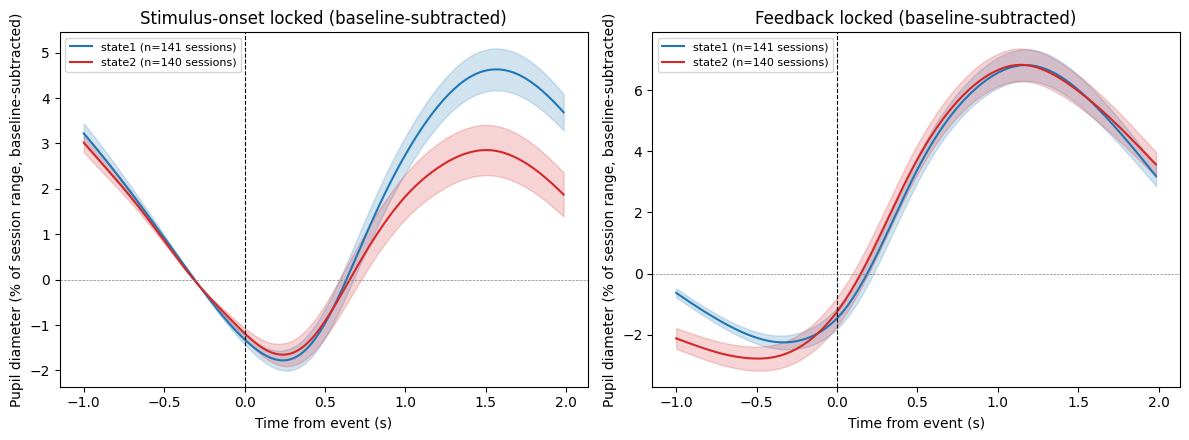

In [9]:
STATE_COLORS = {'state1': 'tab:blue', 'state2': 'tab:red'}
STATE_LABELS = {'state1': 'state1', 'state2': 'state2'}


def plot_state_psth(ax, axis, session_psth_dict, title,
                     ylabel='Pupil diameter (% of session range, baseline-subtracted)'):
    for state, sessions in session_psth_dict.items():
        if len(sessions) == 0:
            continue
        mat = np.vstack(sessions)  # sessions x time
        mean = np.nanmean(mat, axis=0)
        sem = np.nanstd(mat, axis=0) / np.sqrt(np.sum(~np.isnan(mat), axis=0))
        ax.plot(axis, mean, color=STATE_COLORS[state], label=f'{STATE_LABELS[state]} (n={mat.shape[0]} sessions)')
        ax.fill_between(axis, mean - sem, mean + sem, color=STATE_COLORS[state], alpha=0.2)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Time from event (s)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_state_psth(axes[0], STIM_FULL_AXIS, session_stim_psth, 'Stimulus-onset locked (baseline-subtracted)')
plot_state_psth(axes[1], FB_FULL_AXIS, session_fb_psth, 'Feedback locked (baseline-subtracted)')
plt.tight_layout()
plt.show()


## Pupil PSTHs without baseline subtraction

Same underlying traces, but without subtracting each trial's pre-stimulus baseline, so the
state1-vs-state2 gap in absolute pupil level is visible directly (both in the pre-stimulus
period itself and carried through the evoked response).

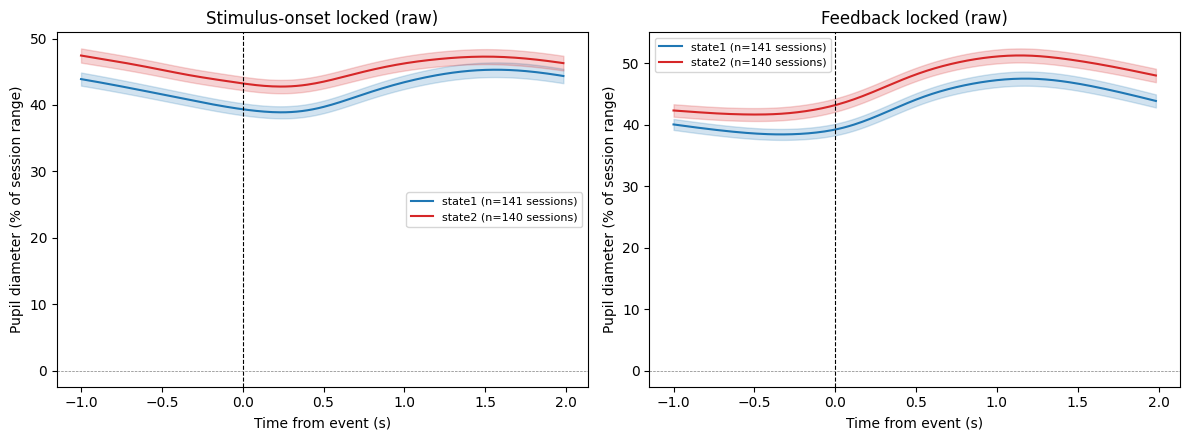

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_state_psth(axes[0], STIM_FULL_AXIS, session_stim_psth_raw, 'Stimulus-onset locked (raw)',
                 ylabel='Pupil diameter (% of session range)')
plot_state_psth(axes[1], FB_FULL_AXIS, session_fb_psth_raw, 'Feedback locked (raw)',
                 ylabel='Pupil diameter (% of session range)')
plt.tight_layout()
plt.show()


## Mixed-effects model helper

Trial-level alternative to the per-session/per-mouse Wilcoxon tests above. Trials are not
independent within a session, so `fit_state_mixedlm` fits `response_col ~ C(dominant_state)`
with a random intercept per session (`groups='eid'`) directly on all trials -- no manual
two-stage session->mouse averaging, and sessions are weighted by how much information they
actually carry (trial count) rather than each contributing one equally-weighted point.

In [11]:
def fit_state_mixedlm(df, response_col, group_col='eid'):
    """Trial-level mixed model: response_col ~ C(dominant_state), random intercept per
    group_col (session). Returns (coef, se, p, fitted_model) for the state2-vs-state1 term."""
    data = df[[response_col, 'dominant_state', group_col]].dropna()
    result = smf.mixedlm(f'{response_col} ~ C(dominant_state)', data=data, groups=data[group_col]).fit()
    key = 'C(dominant_state)[T.state2]'
    return result.params[key], result.bse[key], result.pvalues[key], result


## Baseline pupil size: engaged vs. disengaged

This is the **pre-stimulus** baseline (`BASELINE_WIN = (-0.5, -0.1)` relative to `stimOn_times`,
see `compute_trial_pupil` above) -- i.e. stimulus-locked, not feedback-locked. The same baseline
value is reused when computing both the stim- and feedback-locked evoked responses below, so this
number is not affected by which event the *response* window is aligned to.

Aggregated per session first, then per mouse (mean across that mouse's sessions), to avoid
pseudoreplication -- same approach `load_states.ipynb` uses for stickiness vs. LDA-1 -- plus a
trial-level mixed model as a second, more direct test of the same effect.

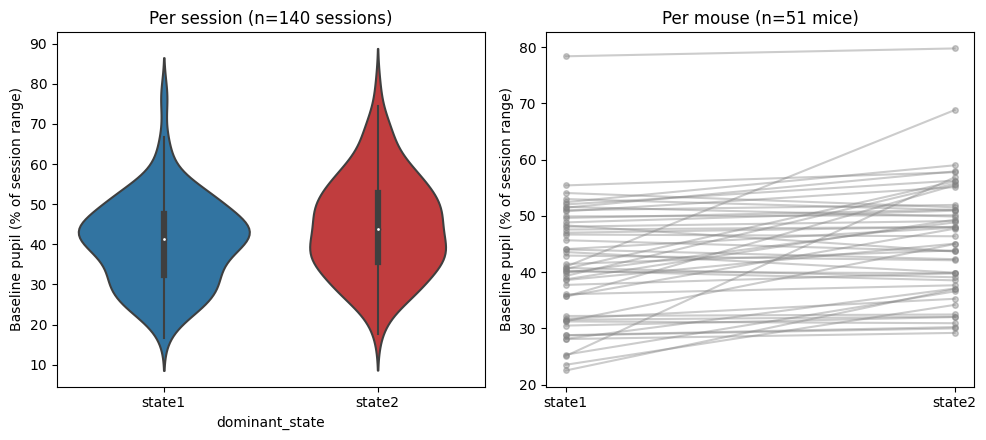

Wilcoxon signed-rank (per-mouse state1 vs state2 baseline pupil): stat=244.00, p=0.0001


Mixed model (trial-level, random intercept per session): state2 - state1 = 2.575 +/- 0.194 (% of session range), p=3.735e-40


In [12]:
session_state_means = pupil_trial_df.groupby(['animal', 'eid', 'dominant_state'])['baseline_pupil'].mean().reset_index()
pivot = session_state_means.pivot_table(index=['animal', 'eid'], columns='dominant_state', values='baseline_pupil').dropna()

mouse_means = pivot.reset_index().groupby('animal')[['state1', 'state2']].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.violinplot(data=pivot.reset_index()[['state1', 'state2']], ax=axes[0], palette=STATE_COLORS)
axes[0].set_ylabel('Baseline pupil (% of session range)')
axes[0].set_title(f'Per session (n={len(pivot)} sessions)')

for _, row in mouse_means.iterrows():
    axes[1].plot([0, 1], [row['state1'], row['state2']], color='gray', alpha=0.4, marker='o', markersize=4)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['state1', 'state2'])
axes[1].set_ylabel('Baseline pupil (% of session range)')
axes[1].set_title(f'Per mouse (n={len(mouse_means)} mice)')
plt.tight_layout()
plt.show()

stat, p = wilcoxon(mouse_means['state1'], mouse_means['state2'])
print(f'Wilcoxon signed-rank (per-mouse state1 vs state2 baseline pupil): stat={stat:.2f}, p={p:.4f}')

coef, se, p_mm, _ = fit_state_mixedlm(pupil_trial_df, 'baseline_pupil')
print(f'Mixed model (trial-level, random intercept per session): '
      f'state2 - state1 = {coef:.3f} +/- {se:.3f} (% of session range), p={p_mm:.4g}')


## Stimulus/feedback response magnitude: engaged vs. disengaged

`stim_pupil_peak`/`fb_pupil_peak` (and the `_mean`/`_auc` variants) are all computed from
`stim_traces`/`fb_traces` in `compute_trial_pupil`, which are baseline-subtracted -- so every
test below (Wilcoxon, mixed model, and the LDA-1 interaction further down) is testing the
*evoked change* relative to each trial's own pre-stimulus baseline, not the absolute pupil
level (that's what the `baseline_pupil` tests above are for).

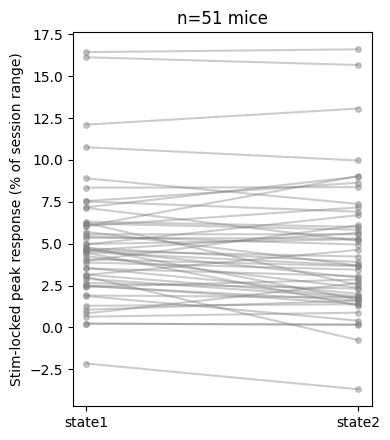

Stim-locked peak response: Wilcoxon per-mouse state1 vs state2, stat=439.00, p=0.0358


Stim-locked peak response: mixed model (random intercept per session) state2 - state1 = -0.181 +/- 0.104, p=0.08094


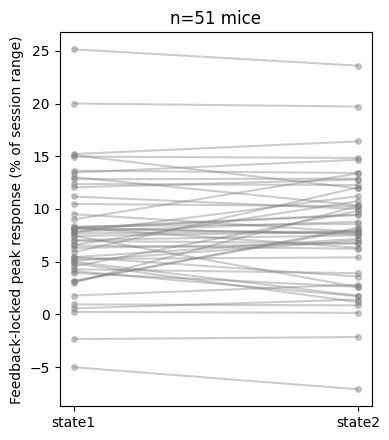

Feedback-locked peak response: Wilcoxon per-mouse state1 vs state2, stat=594.00, p=0.5178


Feedback-locked peak response: mixed model (random intercept per session) state2 - state1 = 0.234 +/- 0.143, p=0.1012


In [13]:
for metric, label in [('stim_pupil_peak', 'Stim-locked peak response'),
                      ('fb_pupil_peak', 'Feedback-locked peak response')]:
    session_state_means = pupil_trial_df.groupby(['animal', 'eid', 'dominant_state'])[metric].mean().reset_index()
    pivot = session_state_means.pivot_table(index=['animal', 'eid'], columns='dominant_state', values=metric).dropna()
    mouse_means = pivot.reset_index().groupby('animal')[['state1', 'state2']].mean()

    fig, ax = plt.subplots(figsize=(4, 4.5))
    for _, row in mouse_means.iterrows():
        ax.plot([0, 1], [row['state1'], row['state2']], color='gray', alpha=0.4, marker='o', markersize=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['state1', 'state2'])
    ax.set_ylabel(f'{label} (% of session range)')
    ax.set_title(f'n={len(mouse_means)} mice')
    plt.tight_layout()
    plt.show()

    stat, p = wilcoxon(mouse_means['state1'], mouse_means['state2'])
    print(f'{label}: Wilcoxon per-mouse state1 vs state2, stat={stat:.2f}, p={p:.4f}')

    coef, se, p_mm, _ = fit_state_mixedlm(pupil_trial_df, metric)
    print(f'{label}: mixed model (random intercept per session) '
          f'state2 - state1 = {coef:.3f} +/- {se:.3f}, p={p_mm:.4g}')


## Why did the stim-locked Wilcoxon and mixed model disagree?

The stim-locked peak response PSTH shows a visually clear average separation between states, and
the per-mouse Wilcoxon reached significance (p=0.036), but the trial-level mixed model above did
not quite (p=0.081). Two things can produce that: (1) different weighting -- Wilcoxon collapses to
one point per mouse regardless of session/trial count, while the mixed model weights by how much
trial-level data each session/mouse actually has, so a few high-trial-count sessions with a small
or reversed effect can pull the trial-weighted average toward null even if most sessions
individually go the same direction; (2) genuine between-session heterogeneity in the size of the
effect, which a random-*intercept*-only model doesn't separately account for (it assumes one fixed
state-effect magnitude shared by every session). Checking both below: the distribution of
per-session effects, and a random-*slope* model that lets each session have its own state effect.

Random-slope model (stim_pupil_peak): state2 - state1 = -0.214 +/- 0.175, p=0.2215
                      Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        stim_pupil_peak
No. Observations:        86259          Method:                    REML           
No. Groups:              141            Scale:                     86.2810        
Min. group size:         401            Log-Likelihood:            -315035.0832   
Max. group size:         1525           Converged:                 Yes            
Mean group size:         611.8                                                    
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                5.301    0.328 16.168 0.000  4.658  5.943
C(dominant_state)[T.state2]

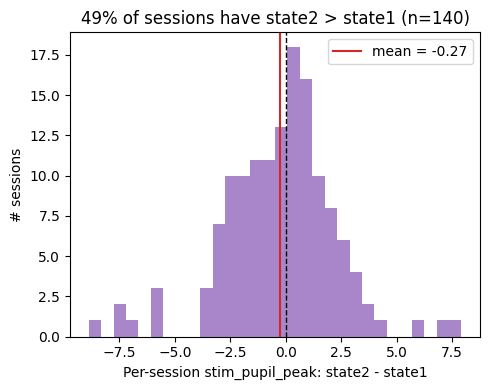

In [14]:
def fit_state_mixedlm_randomslope(df, response_col, group_col='eid'):
    """Same fixed-effect test as fit_state_mixedlm, but with a random slope for
    dominant_state per session (not just a random intercept) -- lets each session have its own
    effect magnitude, diagnosing whether cross-session heterogeneity is diluting significance
    in the simpler (intercept-only) model."""
    data = df[[response_col, 'dominant_state', group_col]].dropna()
    result = smf.mixedlm(f'{response_col} ~ C(dominant_state)', data=data, groups=data[group_col],
                          re_formula='~C(dominant_state)').fit()
    key_rs = 'C(dominant_state)[T.state2]'
    return result.params[key_rs], result.bse[key_rs], result.pvalues[key_rs], result


coef, se, p_rs, rs_model = fit_state_mixedlm_randomslope(pupil_trial_df, 'stim_pupil_peak')
print(f'Random-slope model (stim_pupil_peak): state2 - state1 = {coef:.3f} +/- {se:.3f}, p={p_rs:.4g}')
print(rs_model.summary())

# Distribution of per-session effects (paired sessions only, i.e. both states occurred there)
session_state_means = pupil_trial_df.groupby(['animal', 'eid', 'dominant_state'])['stim_pupil_peak'].mean().reset_index()
pivot = session_state_means.pivot_table(index=['animal', 'eid'], columns='dominant_state', values='stim_pupil_peak').dropna()
session_diff = pivot['state2'] - pivot['state1']

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(session_diff, bins=30, color='tab:purple', alpha=0.8)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.axvline(session_diff.mean(), color='tab:red', linestyle='-', linewidth=1.5,
           label=f'mean = {session_diff.mean():.2f}')
ax.set_xlabel('Per-session stim_pupil_peak: state2 - state1')
ax.set_ylabel('# sessions')
ax.set_title(f'{(session_diff > 0).mean() * 100:.0f}% of sessions have state2 > state1 (n={len(session_diff)})')
ax.legend()
plt.tight_layout()
plt.show()


## LDA-1 vs overall pupil size (independent of engagement state)

Simple per-session (then per-mouse, to avoid pseudoreplication) correlation between LDA-1 and
mean pupil metrics **pooled across both states** -- same style as the `stickiness`/`state_ratio`
vs. `lda_1` plots in `load_states.ipynb`. This is a different question from the interaction
models further below: those ask "does the *state1-vs-state2 gap* scale with LDA-1?"; this asks
"does LDA-1 predict pupil at all, regardless of which state a trial happens to be in?"

baseline_pupil per-session (n=141): Pearson r=0.068 (p=0.4200), Spearman r=0.067 (p=0.4280)
baseline_pupil per-mouse (n=51): Pearson r=-0.040 (p=0.7805)


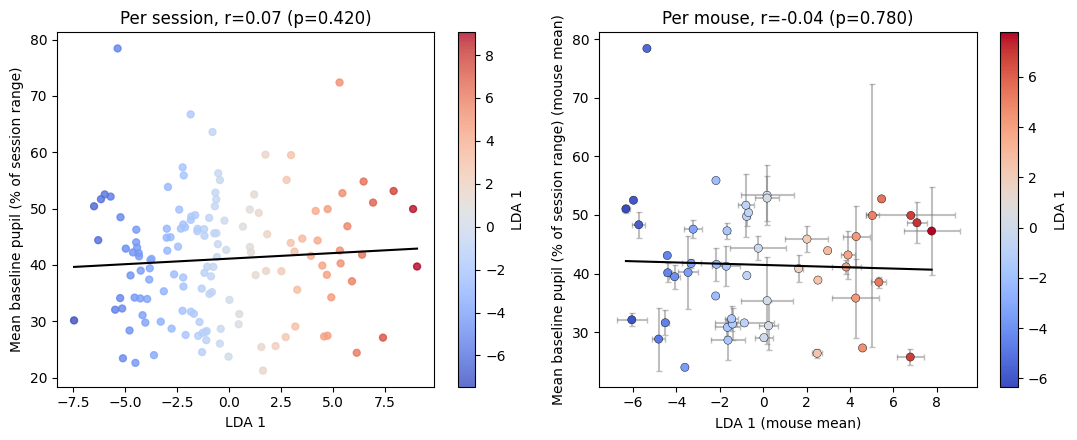

In [15]:
def plot_lda1_vs_overall_metric(metric_col, ylabel):
    """Per-session and per-mouse correlation between LDA-1 and metric_col, pooled across
    dominant_state (i.e. a plain session-level mean, not split by state)."""
    session_metric = pupil_trial_df.groupby('eid')[metric_col].mean().rename('metric').reset_index()
    session_metric = session_metric.merge(matched[['session', 'lda_1', 'mouse_name']], left_on='eid', right_on='session')

    r_p, p_p = pearsonr(session_metric['lda_1'], session_metric['metric'])
    r_s, p_s = spearmanr(session_metric['lda_1'], session_metric['metric'])
    print(f'{metric_col} per-session (n={len(session_metric)}): Pearson r={r_p:.3f} (p={p_p:.4f}), '
          f'Spearman r={r_s:.3f} (p={p_s:.4f})')

    mouse_metric = session_metric.groupby('mouse_name').agg(
        lda1_mean=('lda_1', 'mean'), lda1_sem=('lda_1', 'sem'),
        metric_mean=('metric', 'mean'), metric_sem=('metric', 'sem'),
    ).reset_index()
    mouse_metric[['lda1_sem', 'metric_sem']] = mouse_metric[['lda1_sem', 'metric_sem']].fillna(0)
    r_pm, p_pm = pearsonr(mouse_metric['lda1_mean'], mouse_metric['metric_mean'])
    print(f'{metric_col} per-mouse (n={len(mouse_metric)}): Pearson r={r_pm:.3f} (p={p_pm:.4f})')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    sc = axes[0].scatter(session_metric['lda_1'], session_metric['metric'], c=session_metric['lda_1'], cmap='coolwarm', alpha=0.8, s=25)
    a, b = np.polyfit(session_metric['lda_1'], session_metric['metric'], 1)
    x_range = np.linspace(session_metric['lda_1'].min(), session_metric['lda_1'].max(), 100)
    axes[0].plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    axes[0].set_xlabel('LDA 1')
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(f'Per session, r={r_p:.2f} (p={p_p:.3f})')
    fig.colorbar(sc, ax=axes[0], label='LDA 1')

    axes[1].errorbar(mouse_metric['lda1_mean'], mouse_metric['metric_mean'],
                      xerr=mouse_metric['lda1_sem'], yerr=mouse_metric['metric_sem'],
                      fmt='none', ecolor='gray', alpha=0.5, capsize=2, zorder=1)
    sc2 = axes[1].scatter(mouse_metric['lda1_mean'], mouse_metric['metric_mean'], c=mouse_metric['lda1_mean'],
                          cmap='coolwarm', s=35, zorder=2, edgecolor='k', linewidth=0.3)
    a, b = np.polyfit(mouse_metric['lda1_mean'], mouse_metric['metric_mean'], 1)
    x_range = np.linspace(mouse_metric['lda1_mean'].min(), mouse_metric['lda1_mean'].max(), 100)
    axes[1].plot(x_range, a * x_range + b, color='k', linewidth=1.5)
    axes[1].set_xlabel('LDA 1 (mouse mean)')
    axes[1].set_ylabel(ylabel + ' (mouse mean)')
    axes[1].set_title(f'Per mouse, r={r_pm:.2f} (p={p_pm:.3f})')
    fig.colorbar(sc2, ax=axes[1], label='LDA 1')

    plt.tight_layout()
    plt.show()
    return session_metric, mouse_metric


_ = plot_lda1_vs_overall_metric('baseline_pupil', 'Mean baseline pupil (% of session range)')


stim_pupil_peak per-session (n=141): Pearson r=0.092 (p=0.2774), Spearman r=0.105 (p=0.2171)
stim_pupil_peak per-mouse (n=51): Pearson r=0.151 (p=0.2910)


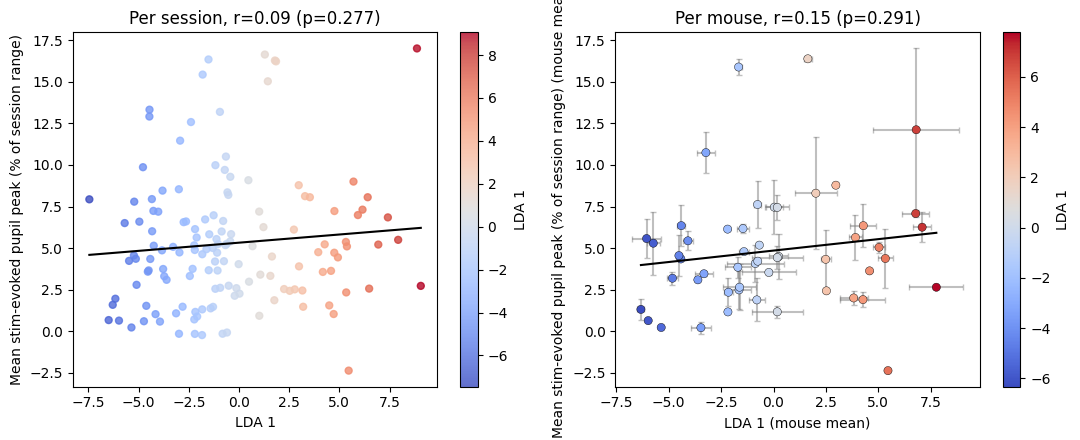

In [16]:
_ = plot_lda1_vs_overall_metric('stim_pupil_peak', 'Mean stim-evoked pupil peak (% of session range)')


## Pupil difference between states, along LDA-1

Does the size of the state1-vs-state2 pupil difference depend on where a session sits on the
LDA-1 axis? Both the state-difference and LDA-1 are already **session-level** quantities (LDA-1
by construction; the state-difference because it's `mean(metric | state2) - mean(metric | state1)`
computed within each session) -- so this is a plain session-level regression
(`state_diff ~ lda_1`, one row per session), not a trial-level mixed model. A trial-level
`C(dominant_state) * lda_1` model (tried earlier) folds in a `C(dominant_state)` main-effect term
that's redundant once the outcome is already the state2-minus-state1 difference -- that
main-effect coefficient is absorbed into how `state_diff` itself is constructed, and there's no
remaining trial-level clustering to account for after collapsing to one row per session, so no
random effects are needed either. Done below for both `stim_pupil_peak` (evoked, baseline-
subtracted) and `baseline_pupil` (absolute).

141 sessions with pupil data + LDA-1 (51 mice), 86259 trials
stim_pupil_peak state_diff ~ lda_1 (n=140 sessions): coef=0.0184, se=0.0594, p=0.7569, R2=0.0007


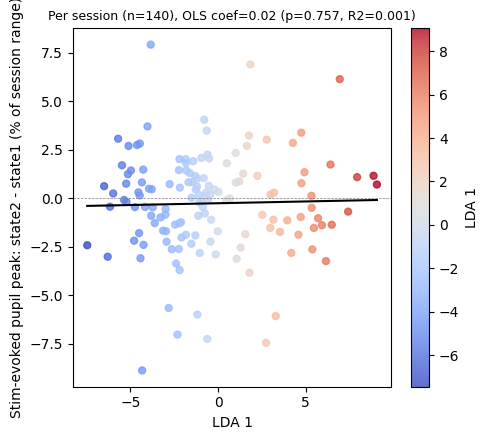

In [17]:
lda1_trials = pupil_trial_df.merge(matched[['session', 'lda_1']], left_on='eid', right_on='session', how='inner')
lda1_trials = lda1_trials.dropna(subset=['stim_pupil_peak', 'lda_1', 'dominant_state'])
print(f'{lda1_trials["eid"].nunique()} sessions with pupil data + LDA-1 '
      f'({lda1_trials["animal"].nunique()} mice), {len(lda1_trials)} trials')


def test_state_diff_vs_lda1(metric_col, ylabel, use_abs=False):
    """Session-level regression of the state2-minus-state1 difference in metric_col against
    LDA-1 -- one row per session, plain OLS (no mixed model: there's no repeated-measures
    structure left once each session has been collapsed to a single difference score).
    use_abs=True tests the *magnitude* of the state-modulation (|state2 - state1|) instead of
    the signed difference -- relevant because stim_pupil_peak's signed difference was found to
    be ~50/50 in sign across sessions (see the random-slope diagnostic above), so a signed
    regression can't detect an LDA-1 relationship with how *big* the state effect is,
    independent of which direction it happens to go in a given session."""
    session_metric = lda1_trials.groupby(['eid', 'dominant_state'])[metric_col].mean().reset_index()
    pivot = session_metric.pivot_table(index='eid', columns='dominant_state', values=metric_col).dropna()
    pivot['state_diff'] = pivot['state2'] - pivot['state1']
    if use_abs:
        pivot['state_diff'] = pivot['state_diff'].abs()
    pivot = pivot.merge(matched[['session', 'lda_1']], left_index=True, right_on='session')

    ols_result = smf.ols('state_diff ~ lda_1', data=pivot).fit()
    coef, se, p_val = ols_result.params['lda_1'], ols_result.bse['lda_1'], ols_result.pvalues['lda_1']
    print(f'{metric_col} state_diff ~ lda_1 (n={len(pivot)} sessions): '
          f'coef={coef:.4f}, se={se:.4f}, p={p_val:.4g}, R2={ols_result.rsquared:.4f}')

    fig, ax = plt.subplots(figsize=(5, 4.5))
    sc = ax.scatter(pivot['lda_1'], pivot['state_diff'], c=pivot['lda_1'], cmap='coolwarm', alpha=0.8, s=25)
    x_range = np.linspace(pivot['lda_1'].min(), pivot['lda_1'].max(), 100)
    ax.plot(x_range, coef * x_range + ols_result.params['Intercept'], color='k', linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('LDA 1')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Per session (n={len(pivot)}), OLS coef={coef:.2f} (p={p_val:.3f}, R2={ols_result.rsquared:.3f})',
                 fontsize=9)
    fig.colorbar(sc, ax=ax, label='LDA 1')
    plt.tight_layout()
    plt.show()
    return pivot, ols_result


_ = test_state_diff_vs_lda1('stim_pupil_peak', 'Stim-evoked pupil peak: state2 - state1 (% of session range)')


baseline_pupil state_diff ~ lda_1 (n=140 sessions): coef=0.1785, se=0.2154, p=0.4087, R2=0.0050


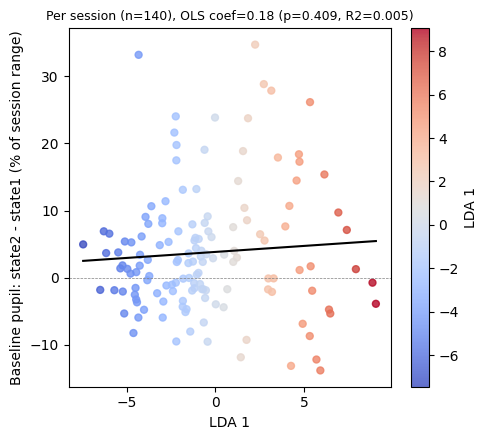

In [18]:
_ = test_state_diff_vs_lda1('baseline_pupil', 'Baseline pupil: state2 - state1 (% of session range)')


### Magnitude of the state difference (absolute value) vs. LDA-1

Same regression, but on `|state2 - state1|` instead of the signed difference -- tests whether
LDA-1 predicts how strongly a session's pupil is modulated by engagement state, regardless of
which direction that modulation happens to go.

stim_pupil_peak state_diff ~ lda_1 (n=140 sessions): coef=0.0110, se=0.0407, p=0.7869, R2=0.0005


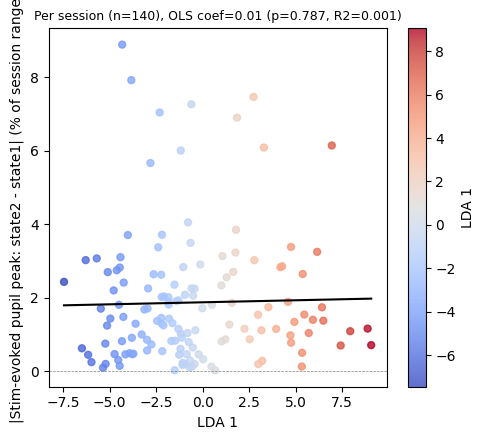

In [19]:
_ = test_state_diff_vs_lda1('stim_pupil_peak', '|Stim-evoked pupil peak: state2 - state1| (% of session range)', use_abs=True)


baseline_pupil state_diff ~ lda_1 (n=140 sessions): coef=0.4517, se=0.1606, p=0.005626, R2=0.0542


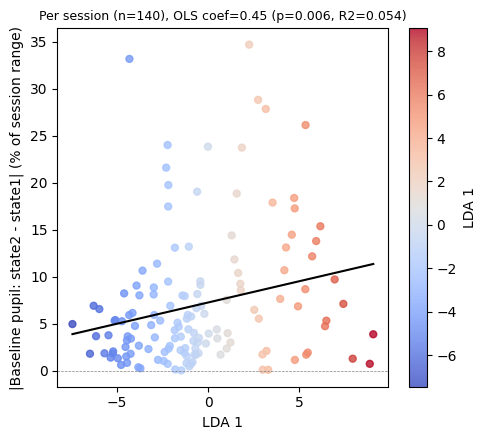

In [20]:
_ = test_state_diff_vs_lda1('baseline_pupil', '|Baseline pupil: state2 - state1| (% of session range)', use_abs=True)


### Does LDA-1 predict evoked pupil independent of state? (main effect, no interaction)

Different question from the interaction models above (which test whether the *state1-vs-state2
gap* scales with LDA-1): this drops the interaction term and asks whether `lda_1` predicts
`stim_pupil_peak` on its own, with `dominant_state` included only as a covariate to control for
(not interact with) -- i.e. an LDA-1 effect that would hold within either state alike. Complements
(does not replace) the plain session/mouse-level correlation in the "independent of engagement
state" section above; this version is trial-level and additionally controls for `dominant_state`
and session/mouse clustering.

In [21]:
main_effect_model = smf.mixedlm(
    'stim_pupil_peak ~ lda_1 + C(dominant_state)',
    data=lda1_trials, groups=lda1_trials['eid'],
).fit()
print(main_effect_model.summary())
print(f"\nlda_1 main effect: coef={main_effect_model.params['lda_1']:.4f}, "
      f"se={main_effect_model.bse['lda_1']:.4f}, p={main_effect_model.pvalues['lda_1']:.4g}")

main_effect_nested = smf.mixedlm(
    'stim_pupil_peak ~ lda_1 + C(dominant_state)',
    data=lda1_trials, groups=lda1_trials['animal'],
    vc_formula={'session': '0 + C(eid)'},
).fit()
print(f"lda_1 main effect (session nested within animal): coef={main_effect_nested.params['lda_1']:.4f}, "
      f"se={main_effect_nested.bse['lda_1']:.4f}, p={main_effect_nested.pvalues['lda_1']:.4g}")


                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    stim_pupil_peak
No. Observations:    86259      Method:                REML           
No. Groups:          141        Scale:                 86.4713        
Min. group size:     401        Log-Likelihood:        -315074.4025   
Max. group size:     1525       Converged:             Yes            
Mean group size:     611.8                                            
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                    5.351    0.331 16.146 0.000  4.701  6.000
C(dominant_state)[T.state2] -0.181    0.104 -1.744 0.081 -0.384  0.022
lda_1                        0.098    0.090  1.086 0.278 -0.079  0.274
Group Var                   15.020    0.196                           


lda_1 main effect: co

lda_1 main effect (session nested within animal): coef=0.0978, se=0.0901, p=0.2775
